In [9]:
## pip install pyjstat

     ---------------------------------------- 0.0/798.0 kB ? eta -:--:--
     - ----------------------------------- 41.0/798.0 kB 667.8 kB/s eta 0:00:02
     -- ---------------------------------- 61.4/798.0 kB 656.4 kB/s eta 0:00:02
     ---- -------------------------------- 92.2/798.0 kB 655.4 kB/s eta 0:00:02
     ----- ------------------------------ 122.9/798.0 kB 658.7 kB/s eta 0:00:02
     ------ ----------------------------- 153.6/798.0 kB 657.6 kB/s eta 0:00:01
     -------- --------------------------- 184.3/798.0 kB 656.9 kB/s eta 0:00:01
     ---------- ------------------------- 225.3/798.0 kB 655.6 kB/s eta 0:00:01
     ----------- ------------------------ 256.0/798.0 kB 655.4 kB/s eta 0:00:01
     ------------ ----------------------- 286.7/798.0 kB 656.7 kB/s eta 0:00:01
     -------------- --------------------- 317.4/798.0 kB 656.4 kB/s eta 0:00:01
     --------------- -------------------- 337.9/798.0 kB 655.4 kB/s eta 0:00:01
     ---------------- ------------------- 368.6

In [11]:
from pyjstat import pyjstat
import requests
from matplotlib import pyplot as plt
import pandas as pd

In [65]:
URL = "https://statistik.konj.se/PxWeb/api/v1/sv/KonjBar/hushall/hushall.px"

hushall = fetch_hushall(URL, "Serie" ,"S")

In [96]:

def fetch_pxweb(url, query):

    payload = {
        "query": query,
        "response": {"format": "json-stat"}
    }

    r = requests.post(url, json=payload)
    r.raise_for_status()

    dataset = pyjstat.Dataset.read(r.text)
    df = dataset.write("dataframe")

    if "Period" in df.columns:
        df["Period"] = pd.to_datetime(df["Period"], format="%YM%m")
        df = df.sort_values("Period")

    return df

In [98]:
URL = "https://statistik.konj.se/PxWeb/api/v1/sv/KonjBar/hushall/hushall.px"

query_hushall = [
    {"code":"Serie","selection":{"filter":"item","values":["S"]}},
    {"code":"Grupp","selection":{"filter":"item","values":["801","802","803","804"]}}
]

hushall = fetch_pxweb(URL, query_hushall)

In [102]:
def plot_one_per_question(df, title_prefix="", qcol=None):

    if qcol is None:
        base = {"Period", "Grupp", "value"}
        extra = [c for c in df.columns if c not in base]
        if not extra:
            raise ValueError(f"Hittar ingen 'fråga'-kolumn. Kolumner: {list(df.columns)}")
        qcol = extra[0]

    print("Using question column:", qcol)

    for q in df[qcol].dropna().unique():
        one = df[df[qcol] == q].copy()

        one = one.dropna(subset=["value"])
        if one.empty:
            print(f"Skip {q}: no values")
            continue

        wide = (one
                .pivot_table(index="Period", columns="Grupp", values="value", aggfunc="first")
                .sort_index())

        wide = wide.dropna(axis=1, how="all")

        plt.figure(figsize=(9,5), dpi=110)

        # rita alla grupper
        for col in wide.columns:
            plt.plot(wide.index, wide[col], label=str(col))

        # visa figuren först efter alla linjer är ritade
        plt.grid(axis="y", color="lightgrey", alpha=0.3)
        plt.title(f"{title_prefix}{q}")
        plt.xlabel("Period")
        plt.ylabel("Värde")
        plt.legend(title="Grupp")
        plt.show()

Using question column: Fråga


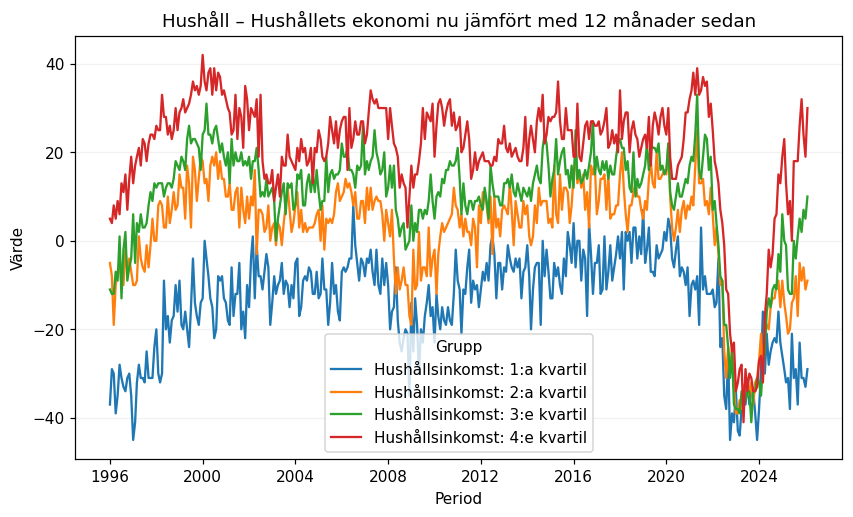

Skip Hushållets ekonomiska situation (lätt - svår att förutsäga): no values


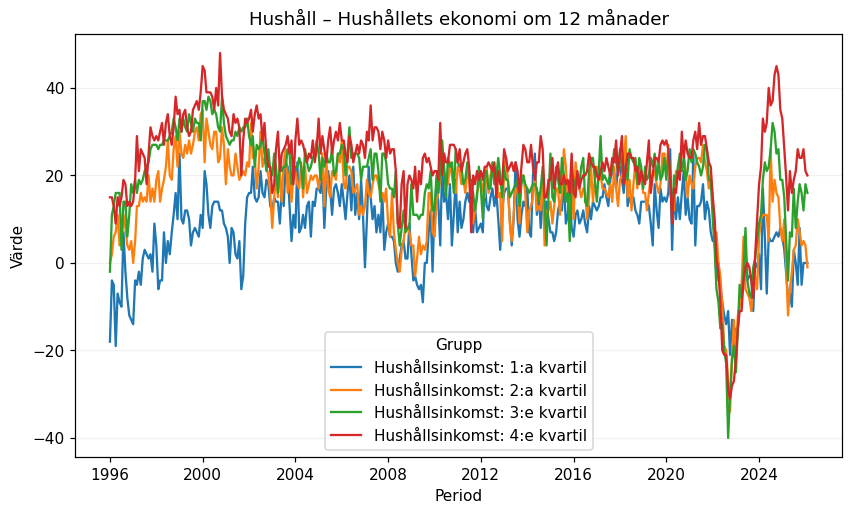

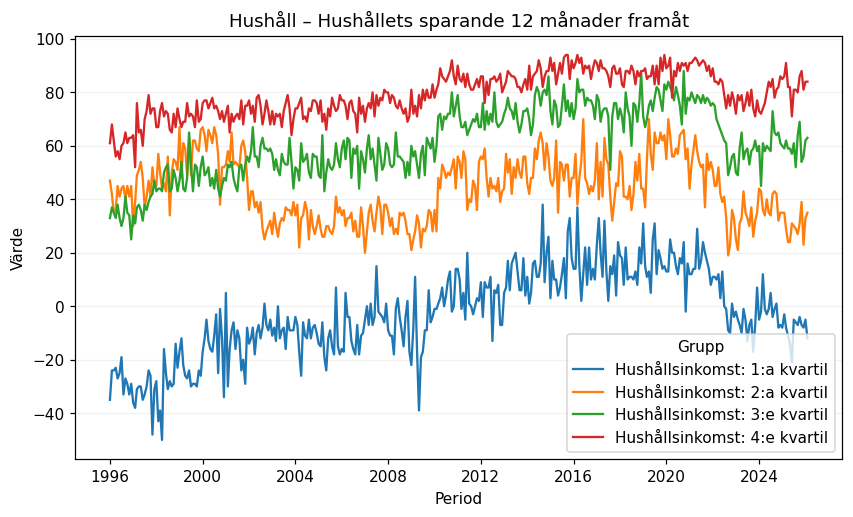

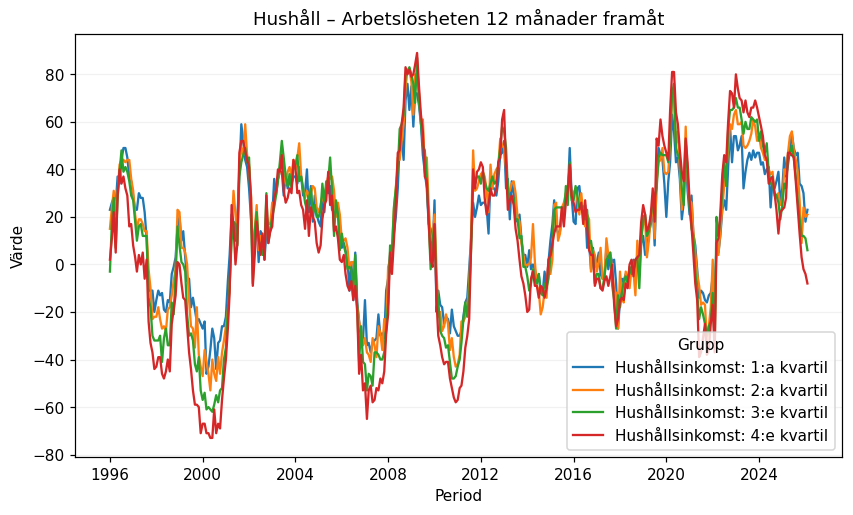

Skip Prisökningstakt 12 månader framåt: no values


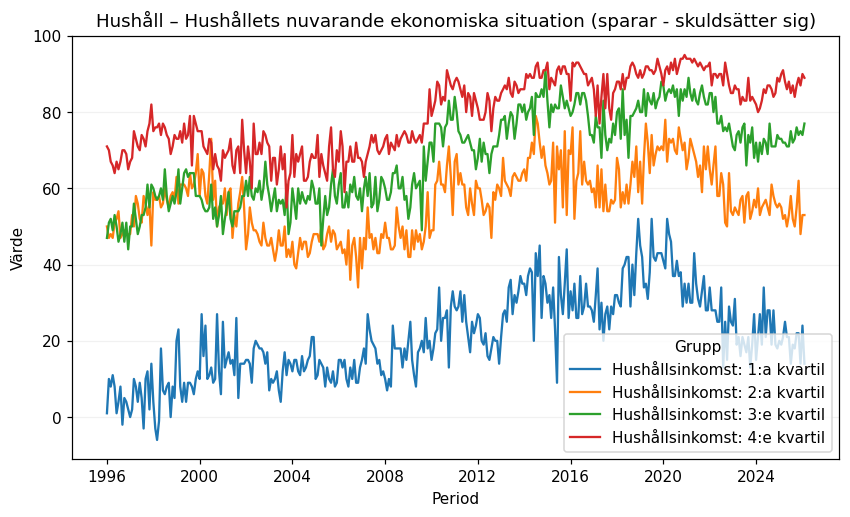

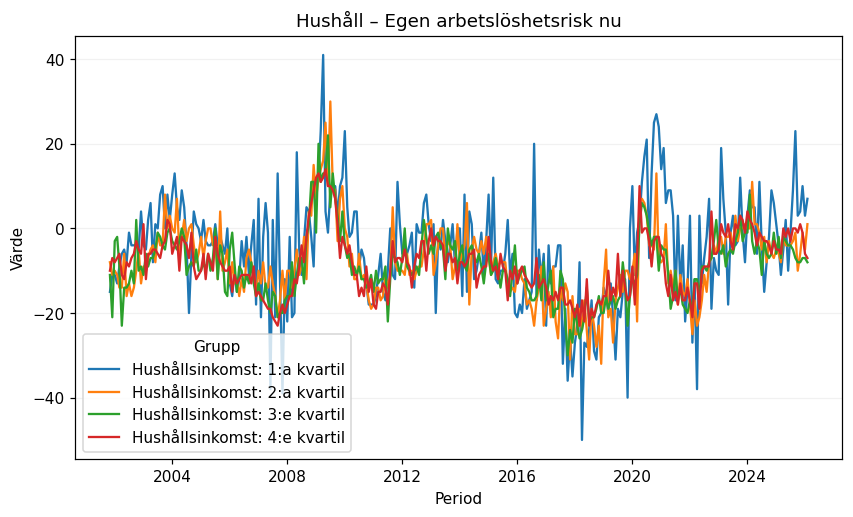

Skip Prisnivå nu: no values


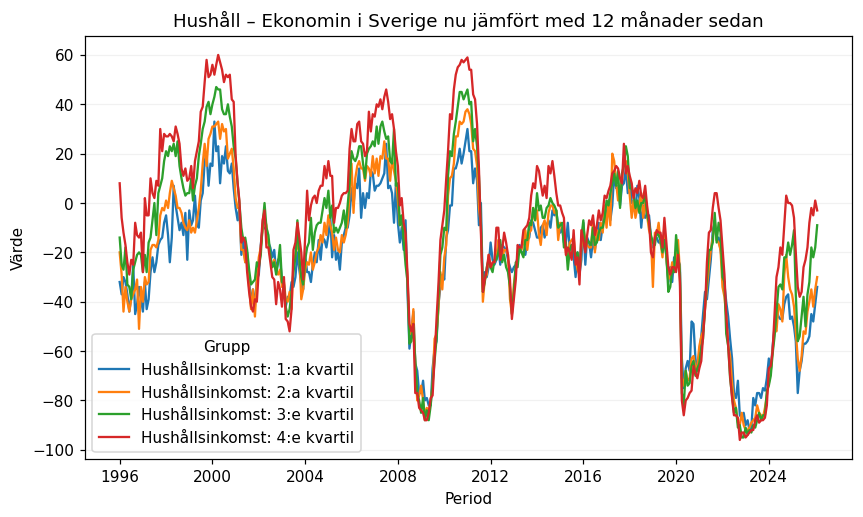

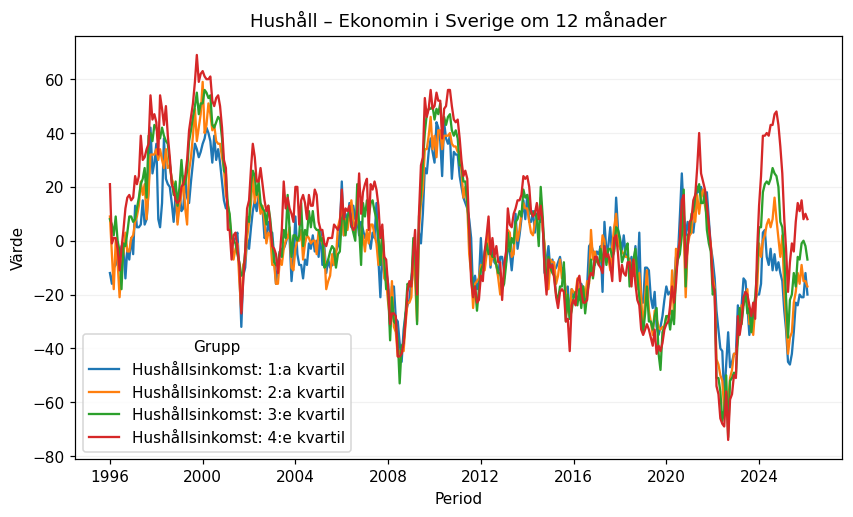

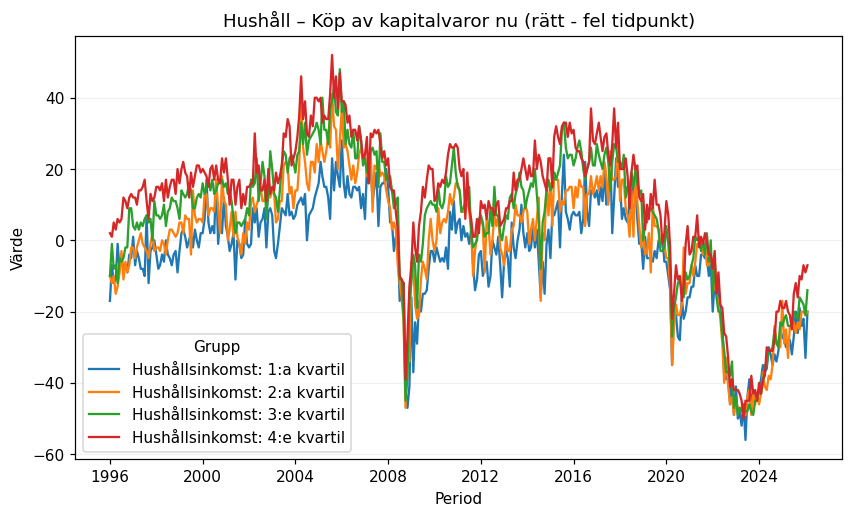

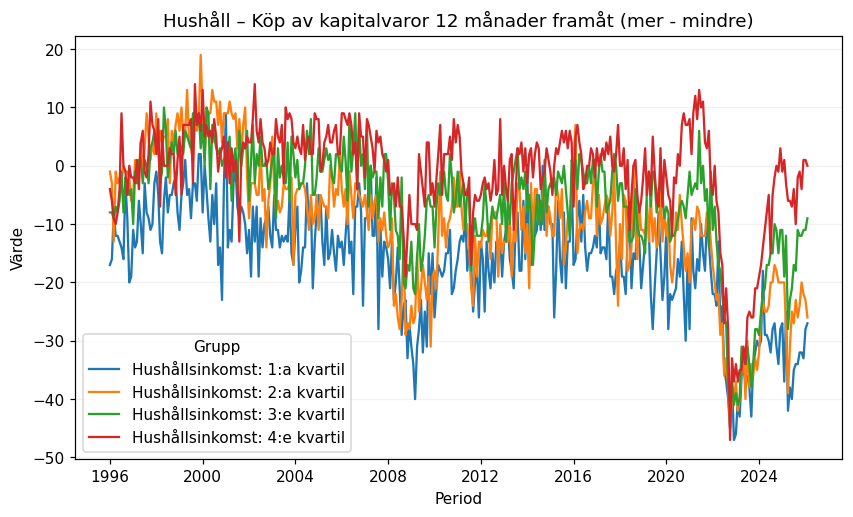

In [100]:
plot_one_per_question(hushall, title_prefix="Hushåll – ")

Using question column: Indikator


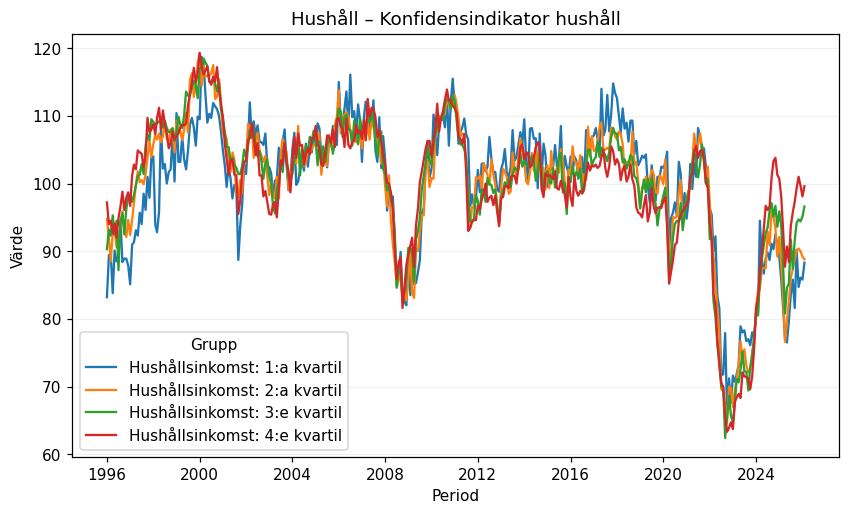

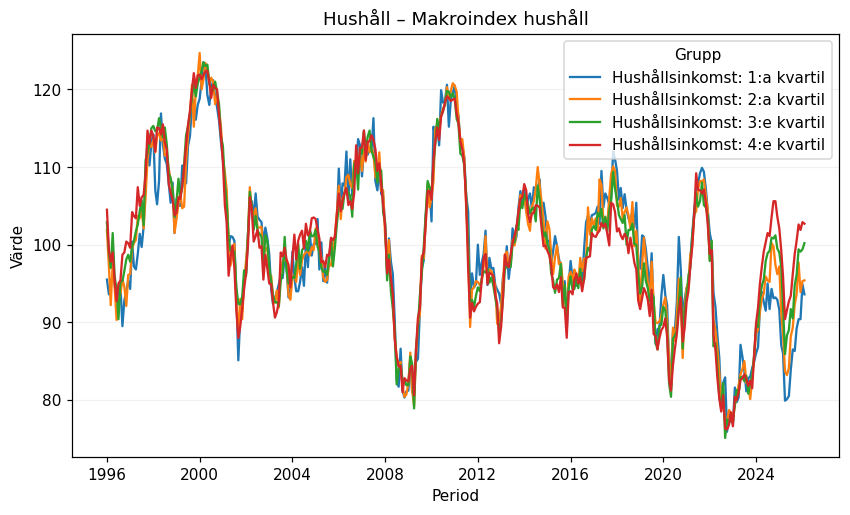

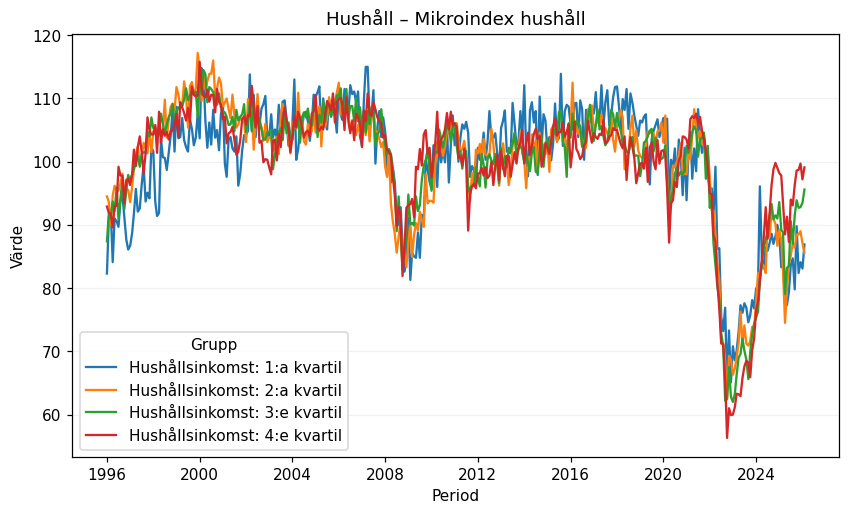

In [106]:
URL1 = "https://statistik.konj.se:443/PxWeb/api/v1/sv/KonjBar/hushall/indikatorhus.px"

query_indikatorhus = [
    {"code":"Grupp","selection":{"filter":"item","values":["801","802","803","804"]}}
]

indikatorhus= fetch_pxweb(URL1, query_indikatorhus)

plot_one_per_question(indikatorhus, title_prefix="Hushåll – ")